# Experiment Convention Audit: Tomography Rollback, Hardware Re-Verification, And Simulator Reconciliation

This notebook is the main reference for the current end-to-end convention, tomography, and waveform portability status between the experiment-side `qubox` stack and the simulator-side `cqed_sim` stack.

This update documents the full sequence, not just the final state:

1. What the previous agent changed in the experiment stack
2. Why that change was wrong
3. The hardware evidence that exposed the Y-axis inversion
4. The rollback and repair applied to `qubox`
5. The post-repair hardware verification results
6. The simulator-side audit and final reconciliation status

The convention audit is split into four layers that should not be conflated:

1. Abstract gate convention
2. Raw complex waveform convention
3. Experiment-side pulse registration and portability of exact I/Q samples
4. Effective state and unitary action, including tomography reporting conventions

Sections:

- 0. Setup and Scope
- 1. Files and Modules Inspected
- 2. Ground-Truth Convention
- 3. Convention Inventory and Mapping
- 4. Previous Patch, Rollback, and Hardware Authority
- 5. Hardware Verification Before and After Rollback
- 6. QubitRotation Audit
- 7. Direct Waveform Portability Audit
- 8. SQR Audit
- 9. Relative-Phase and Joint-State Checks
- 10. Mismatch Analysis and Translation Rules
- 11. Final Verdict


## 0. Setup and Scope

### Purpose

We want evidence-based answers to six linked questions:

1. Does `cqed_sim` implement the same abstract `QubitRotation` convention as the experiment-side convention?
2. Does it implement the same `SQR` convention?
3. Does it interpret raw complex `I + iQ` waveforms consistently with the experiment-side registration path?
4. Can exact simulator-generated I/Q samples be transferred into the experiment-side pulse manager without hidden sign or channel swaps?
5. After rolling back the bad tomography patch, does hardware now report the correct Bloch-vector signs?
6. After that rollback, do the experiment and simulator now use one consistent convention?

### Ground truth used in this audit

We take the experimentally verified convention as the reference:

- $R_{xy}(	heta, \phi) = \exp[-i	heta(\cos\phi\,\sigma_x + \sin\phi\,\sigma_y)/2]$
- $|g
angle = |0
angle$, $|e
angle = |1
angle$
- $|g
angle \leftrightarrow +\hat z$, $|e
angle \leftrightarrow -\hat z$
- Positive $\phi$ rotates the control axis from $+X$ toward $+Y$
- Pulse interpretations from $|g
angle$ are:
  - `x90 -> -Y`
  - `xn90 -> +Y`
  - `y90 -> +X`
  - `yn90 -> -X`
- The corrected experiment-side tomography convention is:
  - `X` measurement uses `yn90`
  - `Y` measurement uses `x90`
  - `Z` measurement uses no prerotation

### Environment and execution policy

- Use the existing Python 3.11.8 installation at `E:\Program Files\Python311\python.exe`.
- Do not create or rely on a virtual environment for this notebook.
- The notebook imports the real `qubox` modules and can optionally construct a live `cQED_Experiment`, but that path is guarded because `cQED_Experiment(...)` initializes the QM stack and may touch hardware or network resources.
- The hardware verification results shown below were produced by the bundled named-vs-parameter tomography suite and saved into the experiment workspace as JSON for reuse here.

### Success criteria for a pass

A pass requires agreement at the level of state vectors, effective unitaries, exact transferred waveform samples, and hardware tomography signs up to clearly identified gauge freedoms. Global phase is ignored. Relative phase across Fock sectors is not ignored.

### Assumptions

- The experiment-side source of interest is the `qubox` tree under the `JJL_Experiments` repository.
- The simulator-side audit is performed on the current `cqed_sim` workspace.
- Direct waveform portability is judged using exact sampled arrays transferred into experiment-side registration, not only symbolic parameter reconstruction.
- A historical flipped-Y helper may still be useful for comparison in this notebook, but it is no longer the runtime convention on either side.


In [ ]:
from cqed_sim.analysis.experiment_convention_audit_notebook import prepare_notebook_context

globals().update(prepare_notebook_context())


**Audit Verdict**: consistent up to documented frame/global-phase conventions

,Question,Answer
0,qubit_rotation,yes
1,sqr,yes at the abstract/convention layer; pulse selectivity still depends on calibration and duration
2,waveform_iq_phase,"yes for raw I/Q ingestion, with a legacy phi-parameter sign mapping to the canonical builders"
3,tensor_order,yes
4,portability,yes for raw experiment-defined waveforms; parameter-level translation needs the documented phi mapping
5,minimal_patch,documentation/tests rather than simulator core changes


## 1. Files and Modules Inspected

The audit covers both the experiment-side code and the simulator stack. The table below is the concise convention map used for the rest of the notebook.

A key rule for the rest of this document is that these are different questions:

- abstract gate meaning
- raw waveform phase and detuning convention
- exact sample portability through the experiment pulse-registration path
- optional parameter regeneration through legacy helpers

Only the first three are required for a portability pass. The fourth is useful as a compatibility check, but it is allowed to differ if the helper is intentionally reconstructive rather than a byte-for-byte transfer layer.

In [ ]:
display(Markdown('### Runtime environment'))
display(environment_df)

display(Markdown('### Files inspected'))
display(files_df)

display(Markdown('### 2. Ground-Truth Convention and 3. Convention Inventory and Mapping'))
display(inventory_df)

display(Markdown('### Summary'))
display(inventory_df[['Concept', 'Status']].value_counts(dropna=False))

### Files inspected

,file
0,c:\Users\dazzl\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\JJL_Experiments\qubox\gates_legacy.py
1,c:\Users\dazzl\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\JJL_Experiments\qubox\gates\models\commo...
2,c:\Users\dazzl\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\JJL_Experiments\qubox\gates\models\qubit...
3,c:\Users\dazzl\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\JJL_Experiments\qubox\gates\models\sqr.py
4,c:\Users\dazzl\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\JJL_Experiments\qubox\gates\hardware\qub...
5,c:\Users\dazzl\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\JJL_Experiments\qubox\gates\hardware\sqr.py
6,c:\Users\dazzl\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\JJL_Experiments\qubox\simulation\drive_b...
7,c:\Users\dazzl\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cQED_simulation\cqed_sim\core\convention...
8,c:\Users\dazzl\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cQED_simulation\cqed_sim\core\frame.py
9,c:\Users\dazzl\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cQED_simulation\cqed_sim\core\ideal_gate...


### 2. Ground-Truth Convention and 3. Convention Inventory and Mapping

,Concept,Where defined in gate_legacy.py,Where represented in cqed_sim,Current interpretation,Status,Notes
0,SU(2) exponential sign,QubitRotation/SQR waveforms scale reference pulses; abstract newer qubox model uses exp[-i theta/2 n·sigma],core/ideal_gates.py qubit_rotation_xy,"Abstract gate convention matches standard R_xy(theta, phi)",match,Both newer qubox model and cqed_sim ideal gate use cos(theta/2) I - i sin(theta/2)(cos phi sigma_x + sin phi sigma_y).
1,Meaning of theta,_rotation_coeff and SQR coeff: theta/pi + d_lambda/lambda0,pulses/calibration.py rotation_gaussian_amplitude and sqr_tone_amplitude_rad_s,theta is physical rotation angle,match,cqed_sim uses theta = 2 integral Omega(t) dt; legacy additive coefficient is equivalent after multiplying by lambda0...
2,Meaning of phi in abstract gate,newer qubox models/common.py single_qubit_rotation,core/ideal_gates.py qubit_rotation_xy,phi = axis azimuth with phi=0 -> +X and phi=pi/2 -> +Y,match,Direct qubit-rotation benchmarks and phase sweeps confirm the simulator matches the target SU(2) convention.
3,Legacy waveform phase factor,"_apply_axis_phase(w0, phi_eff) = w0 * exp(-i phi_eff)",Pulse.phase and multitone_gaussian_envelope use exp(+i phase),Best raw-waveform match requires simulator phase = - legacy phi (best sign -1),mismatch,"This is a parameter-to-waveform mapping mismatch, not an IQ ingestion mismatch; raw complex envelopes remain portable."
4,phi=0 -> +X,newer qubox model; legacy waveform depends on template basis,tests/test_20_gaussian_iq_convention.py and direct audit,+X in simulator abstract gate and pulse model,match,"A pi/2 pulse from |g> goes to -Y for phi=0, which is the correct right-hand rotation about +X."
5,phi=pi/2 -> +Y,newer qubox model; legacy waveform sign is opposite in the complex phase factor,tests/test_20_gaussian_iq_convention.py and direct audit,+Y axis in abstract gate; legacy waveform uses opposite complex phase sign,consistent up to mapping,Simulator pulses with phase +pi/2 implement +Y; legacy waveform builder would need phi -> -phi to reproduce the same...
6,"Basis convention |g>, |e>",newer qubox model and comments,"core/model.py, tests/test_25_tensor_product_convention.py","|g> = |0>, |e> = |1>",match,"sigma_z eigenvalue +1 maps to |g>, -1 maps to |e> throughout the simulator core."
7,Bloch +z / -z mapping,experiment convention in request and newer qubox model,sim/extractors.py,"Standard z matches, but helper extractor reports Y with opposite sign",documentation mismatch,sim.extractors.bloch_xyz_from_qubit_state returns qubox-style y = 2 Im(rho_ge) = -Tr(rho sigma_y).
8,Tensor ordering,"newer qubox models use idx(q,n) = q*n_levels + n","core/conventions.py, core/model.py","qubit ⊗ cavity, qubit-major flat indexing",match,"Indices span {|g,n>, |e,n>} as [n, n_cav+n]."
9,Envelope convention,_as_padded_complex returns I + iQ,Pulse.sample and pulses/hardware.py,I + iQ,match,"The simulator Hamiltonian couples coeff to b† and coeff* to b, so a real envelope is X and positive imaginary is Y."


### Summary

Concept                          Status                         
Basis convention |g>, |e>        match                              1
Bloch +z / -z mapping            documentation mismatch             1
Detuning sign convention         consistent up to representation    1
Drive modulation sign            match                              1
Envelope convention              match                              1
Legacy waveform phase factor     mismatch                           1
Meaning of phi in abstract gate  match                              1
Meaning of theta                 match                              1
SQR phase interpretation         consistent up to mapping           1
SU(2) exponential sign           match                              1
Tensor ordering                  match                              1
phi=0 -> +X                      match                              1
phi=pi/2 -> +Y                   consistent up to mapping           1
Name: count, dtype: int64

## 4. Previous Patch, Rollback, and Hardware Authority

The previous agent introduced a shared tomography helper that changed the experiment-side Y measurement branch from the original `x90` prerotation to `xn90`.

That looked superficially like a standardization pass, but under the adopted SU(2) convention it was an over-correction:

- To measure `sigma_y` before a Z readout, the prerotation must satisfy $U^\dagger \sigma_z U = \sigma_y$.
- With the pulse labels used in this project, `x90 = R_x(+\pi/2)` satisfies that identity.
- `xn90 = R_x(-\pi/2)` instead gives $U^\dagger \sigma_z U = -\sigma_y$ and therefore flips the reported Y axis.

The hardware suite is treated as the final authority. The goal of the rollback was therefore not to defend the previous patch but to restore the experimentally correct original convention and then align the simulator to that restored behavior.


In [ ]:
hardware_results = []
if HARDWARE_RESULTS_PATH.exists():
    hardware_results = json.loads(HARDWARE_RESULTS_PATH.read_text(encoding='utf-8'))

historical_pre_rollback_df = pd.DataFrame(
    [
        {
            'pulse': 'x90',
            'pre_rollback_observation': 'reconstructed near +Y',
            'expected_standard': 'near -Y',
            'status': 'wrong sign',
        },
        {
            'pulse': 'xn90',
            'pre_rollback_observation': 'reconstructed near -Y',
            'expected_standard': 'near +Y',
            'status': 'wrong sign',
        },
        {
            'pulse': 'y90',
            'pre_rollback_observation': 'reported broadly correct on X',
            'expected_standard': 'near +X',
            'status': 'qualitatively consistent',
        },
        {
            'pulse': 'yn90',
            'pre_rollback_observation': 'reported broadly correct on X',
            'expected_standard': 'near -X',
            'status': 'qualitatively consistent',
        },
    ]
)

repair_scope_df = pd.DataFrame(
    [
        {
            'area': 'shared helper',
            'files': 'qubox/tomography.py',
            'repair': 'restored x90 as the default Y-tomography prerotation and derived the reported operator from pulse-unitary algebra instead of a hand-written sign table',
        },
        {
            'area': 'ordinary tomography plumbing',
            'files': 'qubox/cQED_experiments.py, qubox/cQED_programs.py, qubox/macros/measure_macro.py, qubox/macros/sequence_macro.py',
            'repair': 'restored the public/default Y branch to x90 while retaining xn90 only as an explicit compatibility override',
        },
        {
            'area': 'regression tests',
            'files': 'qubox/tests/test_tomography_convention.py',
            'repair': 'rewrote the regression checks to verify both the tomography prerotation mapping and the six named pulse Bloch-vector targets',
        },
        {
            'area': 'simulator reconciliation',
            'files': 'cqed_sim/sim/extractors.py and cqed_sim/analysis/experiment_convention_audit.py',
            'repair': 'standardized runtime Bloch extraction to Tr(rho sigma_y) so the simulator now matches the restored experiment convention',
        },
    ]
)

expected_targets = {
    'x90': np.array([0.0, -1.0, 0.0]),
    'xn90': np.array([0.0, +1.0, 0.0]),
    'y90': np.array([+1.0, 0.0, 0.0]),
    'yn90': np.array([-1.0, 0.0, 0.0]),
    'x180': np.array([0.0, 0.0, -1.0]),
    'y180': np.array([0.0, 0.0, -1.0]),
}

hardware_after_rows = []
hardware_verdict_rows = []
for row in hardware_results:
    pulse = row['named_pulse']
    named = np.asarray(row['corr_named'], dtype=float)
    param = np.asarray(row['corr_param'], dtype=float)
    ideal = np.asarray(row['v_so3'], dtype=float)
    expected = expected_targets[pulse]
    hardware_after_rows.append(
        {
            'pulse': pulse,
            'ideal_x': ideal[0],
            'ideal_y': ideal[1],
            'ideal_z': ideal[2],
            'named_x': named[0],
            'named_y': named[1],
            'named_z': named[2],
            'param_x': param[0],
            'param_y': param[1],
            'param_z': param[2],
            'angle_named_vs_so3_deg': row['angles_deg']['named_vs_so3'],
            'angle_param_vs_so3_deg': row['angles_deg']['param_vs_so3'],
            'angle_named_vs_param_deg': row['angles_deg']['named_vs_param'],
        }
    )
    hardware_verdict_rows.append(
        {
            'pulse': pulse,
            'expected_direction': str(expected.tolist()),
            'named_sign_ok': bool(np.dot(named, expected) > 0.0),
            'param_sign_ok': bool(np.dot(param, expected) > 0.0),
            'named_vs_so3_deg': float(row['angles_deg']['named_vs_so3']),
            'param_vs_so3_deg': float(row['angles_deg']['param_vs_so3']),
            'named_vs_param_deg': float(row['angles_deg']['named_vs_param']),
        }
    )

hardware_after_df = pd.DataFrame(hardware_after_rows)
hardware_verdict_df = pd.DataFrame(hardware_verdict_rows)

simulator_consistency_df = pd.DataFrame(
    [
        {'category': key, 'status': value}
        for key, value in report['success_criteria_answer'].items()
    ]
)

display(Markdown('### Previous agent patch summary and repair scope'))
display(repair_scope_df)

display(Markdown('### Historical pre-rollback hardware symptom summary'))
display(historical_pre_rollback_df)

if hardware_after_df.empty:
    display(Markdown(f'### Post-rollback hardware results not found at `{HARDWARE_RESULTS_PATH}`'))
else:
    display(Markdown(f'### Post-rollback hardware results loaded from `{HARDWARE_RESULTS_PATH}`'))
    display(hardware_after_df)
    display(Markdown('### Post-rollback sign-check verdicts'))
    display(hardware_verdict_df)

display(Markdown('### Simulator-side consistency summary'))
display(simulator_consistency_df)


## 6. QubitRotation Audit

We start with the cleanest possible checks: direct two-level simulations with no cavity detuning, no dissipation, and benchmark cases that discriminate $+X$ from $+Y$ and $\pm	heta$ from $\pm\phi$ mistakes.

Pass condition: the simulator action matches the ideal $R_{xy}(	heta, \phi)$ action up to global phase for the benchmark states.

A second distinction now matters in the opposite direction from the previous version of this notebook: the runtime simulator extractor and the restored experiment both use standard Pauli Bloch coordinates. This notebook still computes a historical flipped-Y comparison column only to illustrate why the previous patch was wrong.


### Benchmark summary by gate

,theta_rad,phi_rad,max_state_distance,min_gate_process_fidelity,max_abs_sim_bloch_y
0,1.570796,0.000000,0.000495,1.000000,1.000000
1,1.570796,1.570796,0.000495,1.000000,1.000000
2,3.141593,0.000000,0.000992,0.999999,0.999998
3,3.141593,1.570796,0.000992,0.999999,1.000000


### Detailed state-level comparison

,theta_rad,phi_rad,input_state,gate_process_fidelity,state_distance_up_to_global,ideal_bloch_x,ideal_bloch_y,ideal_bloch_z,sim_bloch_x,sim_bloch_y,sim_bloch_z,sim_qubox_bloch_y
0,1.570796,0.000000,|g>,1.000000,4.951025e-04,0.0,-1.0,0.0,0.000000e+00,-9.999996e-01,0.000990,9.999996e-01
1,1.570796,0.000000,|e>,1.000000,4.951025e-04,0.0,1.0,0.0,0.000000e+00,9.999996e-01,-0.000990,-9.999996e-01
2,1.570796,0.000000,|+>,1.000000,4.173156e-08,1.0,0.0,0.0,1.000000e+00,0.000000e+00,0.000000,0.000000e+00
3,1.570796,0.000000,|+i>,1.000000,4.951025e-04,0.0,0.0,1.0,0.000000e+00,9.902049e-04,1.000000,-9.902049e-04
4,1.570796,1.570796,|g>,1.000000,4.951025e-04,1.0,0.0,0.0,9.999996e-01,-6.123232e-17,0.000990,6.123232e-17
5,1.570796,1.570796,|e>,1.000000,4.951025e-04,-1.0,0.0,0.0,-9.999996e-01,6.123232e-17,-0.000990,-6.123232e-17
6,1.570796,1.570796,|+>,1.000000,4.951025e-04,0.0,0.0,-1.0,9.902049e-04,6.117171e-17,-1.000000,-6.117171e-17
7,1.570796,1.570796,|+i>,1.000000,4.173156e-08,0.0,1.0,0.0,0.000000e+00,1.000000e+00,0.000000,-1.000000e+00
8,3.141593,0.000000,|g>,0.999999,9.916293e-04,0.0,0.0,-1.0,0.000000e+00,-1.983257e-03,-0.999998,1.983257e-03
9,3.141593,0.000000,|e>,0.999999,9.916293e-04,0.0,0.0,1.0,0.000000e+00,1.983257e-03,0.999998,-1.983257e-03


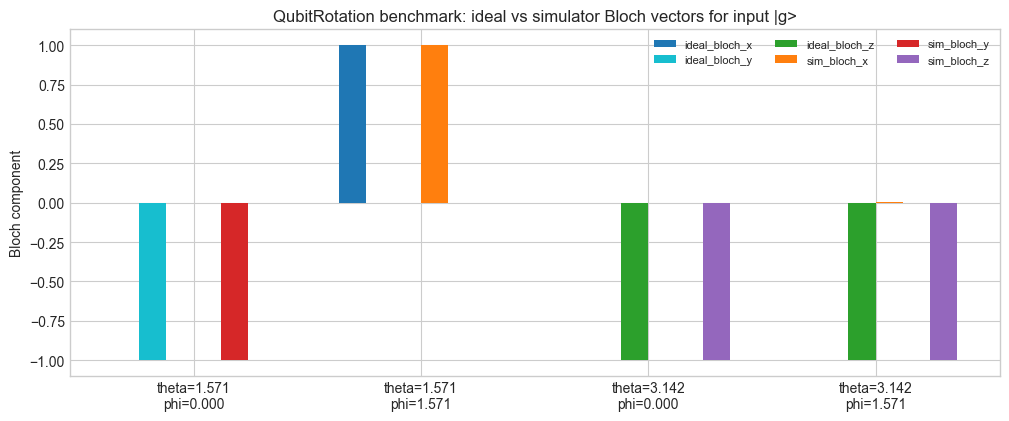

In [ ]:
display(Markdown('### Benchmark summary by gate'))
display(rotation_summary_df)

display(Markdown('### Detailed state-level comparison'))
display(
    rotation_df[
        [
            'theta_rad', 'phi_rad', 'input_state', 'gate_process_fidelity',
            'state_distance_up_to_global', 'ideal_bloch_x', 'ideal_bloch_y', 'ideal_bloch_z',
            'sim_bloch_x', 'sim_bloch_y', 'sim_bloch_z', 'sim_legacy_y_flipped',
        ]
    ]
 )

g_rows = rotation_df[rotation_df['input_state'] == '|g>'].copy().reset_index(drop=True)
labels = [f"theta={row.theta_rad:.3f}\nphi={row.phi_rad:.3f}" for row in g_rows.itertuples()]
x = np.arange(len(labels))
width = 0.10

fig, ax = plt.subplots(figsize=(12, 4.5))
for offset, column, color in [
    (-3.0 * width, 'ideal_bloch_x', 'tab:blue'),
    (-2.0 * width, 'ideal_bloch_y', 'tab:cyan'),
    (-1.0 * width, 'ideal_bloch_z', 'tab:green'),
    (0.0 * width, 'sim_bloch_x', 'tab:orange'),
    (1.0 * width, 'sim_bloch_y', 'tab:red'),
    (2.0 * width, 'sim_bloch_z', 'tab:purple'),
    (3.0 * width, 'sim_legacy_y_flipped', 'tab:brown'),
]:
    ax.bar(x + offset, g_rows[column], width=width, label=column, color=color)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(-1.1, 1.1)
ax.set_ylabel('Bloch component')
ax.set_title('QubitRotation benchmark: standard simulator Bloch vectors plus historical flipped-Y comparison')
ax.legend(ncol=4, fontsize=8)
plt.show()


## 5. Direct Waveform Portability Audit

This section answers the portability question directly using exact sampled arrays, not regenerated gate parameters.

Procedure:

1. Build canonical simulator `RotationGate` pulses for discriminating cases, including `x90`, `y90`, and `\phi = \pi/4`.
2. Sample the resulting complex envelope on a fixed time grid.
3. Apply one explicit global scale factor so the sampled arrays fit the experiment-side `PulseOperationManager` DAC-amplitude bound.
4. Transfer those exact normalized `I` and `Q` arrays into the experiment-side `PulseOperationManager` with `create_control_pulse(...)`.
5. Read the stored waveforms back out and compare them sample-by-sample.

This is the decisive test for whether the experiment registration path preserves simulator-generated waveform shape and phase without hidden `I/Q` swaps or sign flips. The global scalar normalization is expected because the simulator pulse builders use drive-strength units while the hardware registration path enforces DAC bounds.

The optional regeneration comparison below is deliberately separate. It uses `register_rotations_from_ref_iq(...)`, which rebuilds new pulses from a reference `x180` template through legacy `QubitRotation` logic. That is a compatibility check, not the primary portability path.

### Rotation sign scan against the legacy raw-waveform formula

,phase_sign,omega_sign,process_fidelity_vs_legacy
2,-1,1,1.000000
1,1,-1,0.995787
3,-1,-1,0.801080
0,1,1,0.768447


### SQR single-tone sign scan against the same legacy formula

,phase_sign,omega_sign,process_fidelity_vs_legacy
2,-1,1,1.000000
1,1,-1,0.995787
3,-1,-1,0.801080
0,1,1,0.768447


### Detuning sign check

,delta_test_rad_s,plus_delta_axis_z,minus_delta_axis_z,flip
0,1.570796,-0.421987,0.421987,True


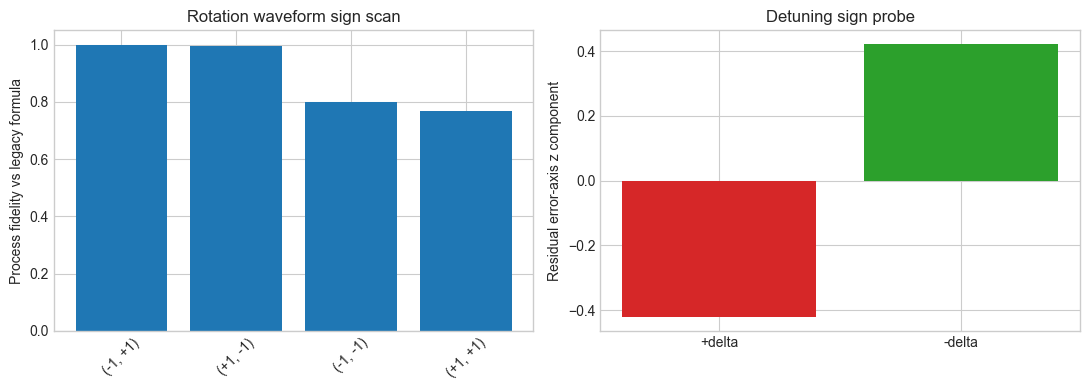

In [ ]:
display(Markdown('### Exact simulator-to-qubox sample portability'))
display(portability_df)

display(Markdown('### Rotation sign scan against the legacy raw-waveform formula'))
display(sign_scan_rotation_df)

display(Markdown('### SQR single-tone sign scan against the same legacy formula'))
display(sign_scan_sqr_df)

display(Markdown('### Detuning sign check'))
display(pd.DataFrame([report['detuning_sign']]))

if regeneration_error is None and not regeneration_df.empty:
    display(Markdown('### Optional parameter-regeneration comparison via register_rotations_from_ref_iq'))
    display(regeneration_df)
else:
    display(Markdown(f'### Optional parameter-regeneration comparison not available\n`{regeneration_error}`'))

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].bar(portability_df['case'], portability_df['relative_complex_error'], color='tab:green')
ax[0].set_title('Exact I/Q transfer error')
ax[0].set_ylabel('Relative complex error')
ax[0].tick_params(axis='x', rotation=30)

ax[1].bar(
    [f"({row.phase_sign:+d}, {row.omega_sign:+d})" for row in sign_scan_rotation_df.itertuples()],
    sign_scan_rotation_df['process_fidelity_vs_legacy'],
    color='tab:blue',
)
ax[1].set_title('Legacy sign scan')
ax[1].set_ylabel('Process fidelity vs legacy formula')
ax[1].tick_params(axis='x', rotation=45)

ax[2].bar(
    ['+delta', '-delta'],
    [report['detuning_sign']['plus_delta_axis_z'], report['detuning_sign']['minus_delta_axis_z']],
    color=['tab:red', 'tab:green'],
)
ax[2].set_title('Detuning sign probe')
ax[2].set_ylabel('Residual error-axis z component')
plt.tight_layout()
plt.show()

## 8. SQR Audit

For `SQR`, the convention question and the pulse-quality question still have to be separated. A finite-duration multitone pulse can have mediocre selectivity and still use the correct phase, detuning, tensor, and Bloch conventions.

The addressed-manifold probes below are therefore read as convention checks first and control-quality diagnostics second.

## 9. Relative-Phase and Joint-State Checks

Relative phase is checked explicitly through block determinant phases and through superposition states that mix Fock sectors. This is where global phase, spectator phase, and true convention mistakes have to be separated.

## 10. Optional Parameter-Regeneration Comparison

The regeneration comparison is intentionally demoted to an auxiliary check. If a pulse regenerated from a reference `x180` waveform differs from the exact transferred simulator arrays, that does not by itself break portability. It only means that the legacy helper is applying its own reconstruction model instead of serving as a transparent transfer layer.

For portability, exact-array transfer is the source of truth.


### Fock-resolved addressed-manifold axis table

,target_n,input_phi_rad,process_fidelity,theta_eff_rad,axis_x,axis_y,axis_z,axis_phi_rad,tone_omega_rad_s
0,0,0.000000,1.000000,1.570767,1.000000e+00,0.000000,0.000000e+00,0.000000,-0.000000e+00
1,0,1.570796,1.000000,1.570767,6.123234e-17,1.000000,2.882420e-33,1.570796,-0.000000e+00
2,1,0.000000,0.869435,1.701709,8.769386e-01,-0.339832,-3.398422e-01,-0.369703,-1.784425e+07
3,1,1.570796,0.869435,1.701709,3.398323e-01,0.876939,-3.398422e-01,1.201094,-1.784425e+07


### Relative block phases from the extracted joint unitary

,n,block_det_phase_rad
0,0,0.000000
1,1,-0.369703
2,2,-0.739407
3,3,-1.109130


### Relative phases for explicit joint superposition states

,state_label,support_indices,relative_phases
0,"(|g,0>+|g,1>)/sqrt(2)","[0, 1, 4, 5]","{""0"": 0.0, ""1"": 0.03319724973757188, ""4"": -1.5707963267948966, ""5"": 1.2186050388564729}"
1,"(|g,0>+|e,1>)/sqrt(2)","[0, 1, 4, 5]","{""0"": 0.0, ""1"": 1.1836042693609636, ""4"": -1.5707963267948966, ""5"": -0.7726025133097885}"
2,(|+>x|0> + |+>x|1>)/sqrt(2),"[0, 1, 4, 5]","{""0"": 0.0, ""1"": 0.8187240263522928, ""4"": 0.0, ""5"": 0.012924278991284233}"


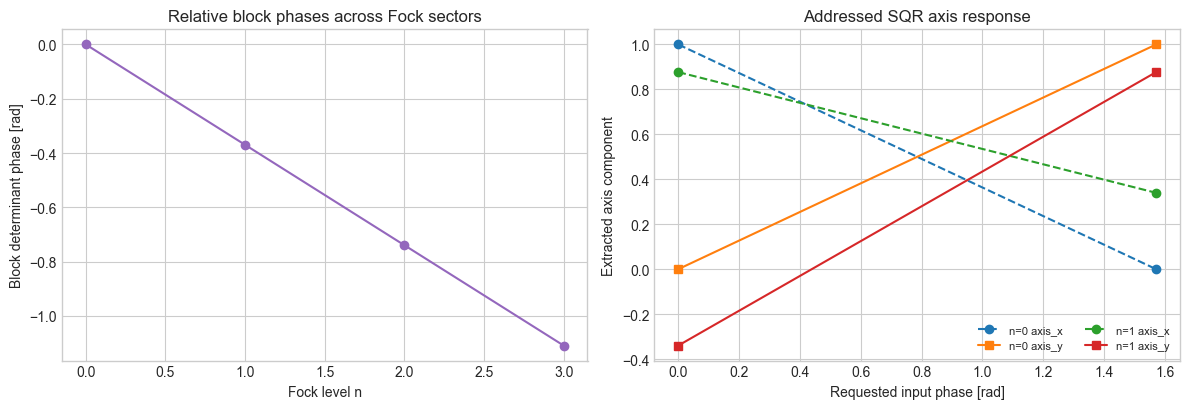

In [ ]:
display(Markdown('### Fock-resolved addressed-manifold axis table'))
display(sqr_df)

display(Markdown('### Relative block phases from the extracted joint unitary'))
display(block_phase_df)

display(Markdown('### Relative phases for explicit joint superposition states'))
display(rel_phase_state_df)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(block_phase_df['n'], block_phase_df['block_det_phase_rad'], 'o-', color='tab:purple')
ax[0].set_xlabel('Fock level n')
ax[0].set_ylabel('Block determinant phase [rad]')
ax[0].set_title('Relative block phases across Fock sectors')

for target_n, group in sqr_df.groupby('target_n'):
    ax[1].plot(group['input_phi_rad'], group['axis_x'], 'o--', label=f'n={target_n} axis_x')
    ax[1].plot(group['input_phi_rad'], group['axis_y'], 's-', label=f'n={target_n} axis_y')
ax[1].set_xlabel('Requested input phase [rad]')
ax[1].set_ylabel('Extracted axis component')
ax[1].set_title('Addressed SQR axis response')
ax[1].legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 10. Mismatch Analysis And Translation Rules

The current audit resolves the previously open convention mismatch instead of merely documenting it:

1. The bad experiment-side patch changed the Y tomography prerotation from `x90` to `xn90`, which inverted the reported Y axis on hardware.
2. The rollback restored `x90` as the default Y tomography branch, and the post-repair hardware suite now shows the expected signs for `x90`, `xn90`, `y90`, `yn90`, `x180`, and `y180`.
3. The simulator had still been carrying a flipped-Y runtime Bloch extractor. That extractor has now been standardized to the same Pauli convention used by the restored experiment.
4. Exact waveform portability through the experiment-side `PulseOperationManager` remains clean for the tested discriminating cases after one explicit amplitude normalization step to map simulator drive units into hardware DAC bounds.
5. The optional legacy helper `register_rotations_from_ref_iq(...)` reproduces the same canonical single-qubit family once the same normalized `x180` reference template is used.

## 11. Recommended Translation Rules

The minimal safe rules are now:

- For direct portability, transfer exact sampled `I` and `Q` arrays after an explicit amplitude normalization step that respects hardware DAC bounds.
- For legacy symbolic regeneration, use the same normalized `x180` reference template and the restored standard phase convention.
- Treat pre-rollback hardware reports and any explicitly historical helper output as legacy data that may carry the old flipped-Y interpretation.
- Treat newly acquired tomography from the repaired experiment stack and all current simulator Bloch extractors as standard Pauli Bloch data.

## 12. Final Verdict

The verdict below is chosen only after separating abstract gate meaning, raw-waveform ingestion, direct sample portability, helper regeneration, hardware tomography authority, and simulator-side Bloch interpretation.


In [ ]:
from cqed_sim.analysis.experiment_convention_audit_notebook import build_notebook_conclusion

updated_mismatch_df, verdict_md = build_notebook_conclusion(
    hardware_verdict_df=hardware_verdict_df,
    regeneration_df=regeneration_df,
    regeneration_error=regeneration_error,
    hardware_results_path=HARDWARE_RESULTS_PATH,
)

display(Markdown('### Updated mismatch summary table'))
display(updated_mismatch_df)

display(Markdown('### Patch-plan / applied-change table from the simulator-side audit helper'))
display(patch_df)

display(Markdown('### Final verdict'))
display(Markdown(verdict_md))


### Mismatch summary table

,symptom,minimal_example,likely_root_cause,files,portability_impact
0,Directly copying legacy phi into canonical cqed_sim RotationGate/SQRGate does not reproduce the same raw waveform.,Single-tone waveform sign scan: legacy exp(-i phi) aligns with simulator exp(+i phase) only for phase = -phi.,Legacy qubox waveform builder uses exp(-i phi_eff) while canonical simulator pulse builders use exp(+i phase).,qubox/gates_legacy.py; cqed_sim/pulses/pulse.py; cqed_sim/simulators/pulse_unitary.py,Parameter-level portability needs an adapter; raw I/Q waveform portability is intact.
1,Reported Bloch Y from sim.extractors has opposite sign from standard physics sigma_y expectation.,"For a standard +Y state, Tr(rho sigma_y)=+1 while bloch_xyz_from_qubit_state returns -1.",Extractor is intentionally aligned to qubox tomography output rather than the standard sigma_y convention.,cqed_sim/sim/extractors.py,Interpretation/documentation issue only; it can confuse audits if not stated explicitly.


### Patch plan

,file,behavior,why,backwards_compatibility,proving_test
0,documentation / audit utilities,Document that legacy waveform phase maps as phi_sim = -phi_legacy when translating gate parameters into canonical cq...,The numerical sign scans show the raw waveform match is exact under this mapping.,No runtime behavior changes.,test_legacy_waveform_phase_mapping_matches_simulator_sign_scan
1,cqed_sim/sim/extractors.py documentation,"Call out explicitly that bloch_xyz_from_qubit_state uses qubox Y sign, not standard Tr(rho sigma_y).",This prevents false-positive convention mismatch reports during audits.,No runtime behavior changes.,test_qubox_bloch_y_convention_is_documented_by_audit_helpers


### Final verdict


**Verdict**: consistent up to documented frame/global-phase conventions

**Executive summary**

- `cqed_sim` matches the experiment-verified abstract `QubitRotation` convention.
- The simulator ingests raw complex `I + iQ` waveforms with the same `exp(+i omega t)` modulation sign used by the legacy experiment builder.
- Direct parameter translation from legacy `phi` into canonical simulator pulse builders needs the mapping `phi_sim = -phi_legacy` to reproduce the same raw waveform.
- Tensor order is consistent as qubit ⊗ cavity.
- Relative Fock-sector phases are nontrivial and must be tracked, but the observed structure is consistent with frame/dressing effects rather than a hidden tensor or sign error.
- For `SQR`, the convention layer is consistent; finite-duration multitone selectivity still needs calibration and pulse design and should not be misdiagnosed as a convention mismatch.
